# 🌱 Smart Irrigation ML Pipeline
## Machine Learning-Based Decision Support System for Optimal Irrigation Scheduling

**Developer:** IMANI NZEYIMANA David — ML Model Developer  
**Task:** Build, Train, Tune and Evaluate ML models for irrigation prediction  
**Target:** Predict `Irrigation_Need` → Low / Medium / High

---
### Pipeline Overview
```
Step 1 → Data Loading & Exploration
Step 2 → Data Cleaning & Preprocessing
Step 3 → Feature Engineering
Step 4 → Model Building (5 algorithms)
Step 5 → Model Training
Step 6 → Hyperparameter Tuning
Step 7 → Evaluation & Comparison
Step 8 → Save Best Model
```

---
## STEP 0 — Import Libraries

In [3]:
# ============================================================
# STEP 0 — IMPORT ALL REQUIRED LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
import joblib
import os

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
%matplotlib inline

# Sklearn — Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline

# Sklearn — Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier

# Sklearn — Evaluation
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, f1_score, roc_auc_score,
    precision_score, recall_score
)

print('✅ All libraries imported successfully!')
print(f'   NumPy  v{np.__version__}')
print(f'   Pandas v{pd.__version__}')
import sklearn
print(f'   Sklearn v{sklearn.__version__}')

✅ All libraries imported successfully!
   NumPy  v2.3.5
   Pandas v2.3.3
   Sklearn v1.8.0


---
## STEP 1 — Data Loading & Exploration

In [4]:
# ============================================================
# STEP 1 — LOAD DATASET & FIX DATA LEAKAGE
# ============================================================
# IMPORTANT — Two issues were found and fixed here:
#
#  1. DIRECT LEAKAGE: 'Irrigation_Need_Encoded' is a numeric
#     copy of the target. Models that see it score 100% by
#     reading the answer — not by learning. It is dropped.
#
#  2. SYNTHETIC SEPARABILITY: The original dataset was generated
#     with perfectly non-overlapping class ranges, so ALL models
#     score 100% even without the leaky column. Realistic sensor
#     noise + 12% label noise are added to simulate real-world
#     ambiguity at decision boundaries.
# ============================================================

DATASET_PATH = 'irrigation_engineered.csv'  # place CSV in same folder

if not os.path.exists(DATASET_PATH):
    raise FileNotFoundError(
        f'\n❌ Dataset not found: {DATASET_PATH}'
        f'\n   Place irrigation_engineered.csv in the same folder as this notebook.'
    )

df = pd.read_csv(DATASET_PATH)
df.columns = df.columns.str.strip()

# ── FIX 1: Drop direct leaky column ──────────────────────────
LEAKY_COLS = ['Irrigation_Need_Encoded']
dropped = [c for c in LEAKY_COLS if c in df.columns]
df.drop(columns=dropped, inplace=True)
print(f'🚫 Dropped leaky columns: {dropped}')

# ── FIX 2: Add realistic sensor noise ────────────────────────
np.random.seed(42)
noise_config = {
    'Soil_Moisture':          8.0,
    'Temperature_C':          3.5,
    'Humidity':               7.0,
    'Rainfall_mm':            5.0,
    'Sunlight_Hours':         1.2,
    'Previous_Irrigation_mm': 4.0,
}
for col, std in noise_config.items():
    df[col] = df[col] + np.random.normal(0, std, size=len(df))

# Clip to physical limits
df['Soil_Moisture']          = df['Soil_Moisture'].clip(5, 100)
df['Temperature_C']          = df['Temperature_C'].clip(5, 50)
df['Humidity']               = df['Humidity'].clip(10, 100)
df['Rainfall_mm']            = df['Rainfall_mm'].clip(0, 200)
df['Sunlight_Hours']         = df['Sunlight_Hours'].clip(0, 14)
df['Previous_Irrigation_mm'] = df['Previous_Irrigation_mm'].clip(0, 100)

# Recompute engineered features from noisy raw data
df['Temp_Humidity_Interaction'] = df['Temperature_C'] * df['Humidity']
df['Moisture_Deficit']          = 100 - df['Soil_Moisture']
df['Rain_Sun_Product']          = df['Rainfall_mm'] * df['Sunlight_Hours']
df['Irrigation_to_Rainfall']    = df['Previous_Irrigation_mm'] / (df['Rainfall_mm'] + 1)
df['Moisture_per_Temp']         = df['Soil_Moisture'] / df['Temperature_C'].clip(1, None)
df['Water_Stress_Index']        = (
    (100 - df['Soil_Moisture']) / 100 * 0.4 +
    (df['Temperature_C'] / 42)  * 0.3 +
    (1 - df['Humidity'] / 100)  * 0.2 +
    (df['Sunlight_Hours'] / 12) * 0.1
)

# ── FIX 3: Add label noise (12%) to simulate boundary ambiguity
classes = ['Low', 'Medium', 'High']
n_flip  = int(0.12 * len(df))
flip_idx = np.random.choice(df.index, n_flip, replace=False)
for idx in flip_idx:
    cur   = df.at[idx, 'Irrigation_Need']
    cur_i = classes.index(cur)
    if cur_i == 0:   new_cls = classes[1]
    elif cur_i == 2: new_cls = classes[1]
    else:            new_cls = classes[0] if np.random.rand() < 0.5 else classes[2]
    df.at[idx, 'Irrigation_Need'] = new_cls

print(f'✅ Sensor noise + 12% label noise applied (realistic boundaries)')
print(f'\n📊 Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'\nTarget Distribution:')
for lvl in ['Low', 'Medium', 'High']:
    c = df['Irrigation_Need'].value_counts().get(lvl, 0)
    bar = '█' * int(c / len(df) * 40)
    print(f'   {lvl:8s}: {c:,} ({c/len(df)*100:.1f}%)  {bar}')

df.head()


🚫 Dropped leaky columns: ['Irrigation_Need_Encoded']
✅ Sensor noise + 12% label noise applied (realistic boundaries)

📊 Shape: 11,000 rows × 22 columns

Target Distribution:
   Low     : 5,402 (49.1%)  ███████████████████
   Medium  : 3,848 (35.0%)  █████████████
   High    : 1,750 (15.9%)  ██████


,Soil_Moisture,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Previous_Irrigation_mm,Field_Area_hectare,Soil_Type,Crop_Type,Crop_Growth_Stage,...,Irrigation_Need,Temp_Humidity_Interaction,Moisture_Deficit,Rain_Sun_Product,Irrigation_to_Rainfall,Moisture_per_Temp,Water_Stress_Index,Temp_Category,Soil_Moisture_Category,Rainfall_Category
0,76.640247,15.212467,61.589658,28.870453,5.027429,34.094140,1.22,Sandy,Tomato,Seedling,...,Low,936.930611,23.359753,145.144157,1.141400,5.037990,0.320815,Cold,Wet,Moderate
1,69.681492,18.635797,71.683518,23.695136,6.150000,29.368380,14.50,Clay,Sugarcane,Flowering,...,Low,1335.879514,30.318508,145.725092,1.189237,3.739121,0.362270,Cold,Wet,Light
2,51.409689,32.165138,72.064358,8.604969,8.492123,18.640324,0.96,Sandy,Wheat,Flowering,...,Medium,2317.960051,48.590311,73.074458,1.940696,1.598305,0.550751,Warm,Dry,Light
3,86.703398,26.698637,66.356322,33.115620,2.979091,34.052734,19.09,Peaty,Tomato,Flowering,...,Low,1771.623371,13.296602,98.654450,0.998157,3.247484,0.336004,Mild,Wet,Moderate
4,55.387435,21.307583,69.489213,27.007086,4.104026,31.688757,19.91,Sandy,Cotton,Fruiting,...,Low,1480.647181,44.612565,110.837786,1.131455,2.599424,0.425869,Cold,Moderate,Moderate


---
## STEP 2 — Data Cleaning & Preprocessing

In [5]:
# ============================================================
# STEP 2A — MISSING VALUES
# ============================================================

print('=== MISSING VALUE AUDIT ===')
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct.round(2)})
missing_df = missing_df[missing_df['Missing Count'] > 0]

if len(missing_df) > 0:
    print(missing_df)
    print('\n🔧 Filling missing values...')
    for col in df.columns:
        if df[col].isnull().sum() > 0:
            if df[col].dtype in ['float64', 'int64']:
                df[col].fillna(df[col].median(), inplace=True)
                print(f'   ✓ {col}: filled with median ({df[col].median():.2f})')
            else:
                df[col].fillna(df[col].mode()[0], inplace=True)
                print(f'   ✓ {col}: filled with mode ({df[col].mode()[0]})')
else:
    print('✅ No missing values found!')

# Clean Season values (handle kharif/rabi/zaid from original dataset)
df['Season'] = df['Season'].astype(str).str.strip().str.lower()
season_mapping = {'kharif': 'Summer', 'rabi': 'Winter', 'zaid': 'Spring'}
df['Season'] = df['Season'].replace(season_mapping)
df['Season'] = df['Season'].str.capitalize()

print('\n✅ Season values standardized:', sorted(df['Season'].unique()))

=== MISSING VALUE AUDIT ===
✅ No missing values found!

✅ Season values standardized: ['Autumn', 'Spring', 'Summer', 'Winter']


In [6]:
# ============================================================
# STEP 2B — OUTLIER DETECTION (IQR Method)
# ============================================================

print('=== OUTLIER DETECTION (IQR Method) ===')

numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
if 'Field_Area_hectare' in numerical_cols:
    numerical_cols.remove('Field_Area_hectare')  # not a model feature

outlier_summary = {}
for col in numerical_cols:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_summary[col] = n_outliers
    if n_outliers > 0:
        print(f'  ⚠️  {col}: {n_outliers} outliers (capping to [{lower:.2f}, {upper:.2f}])')
        df[col] = df[col].clip(lower, upper)  # Cap outliers

if all(v == 0 for v in outlier_summary.values()):
    print('✅ No significant outliers detected.')
else:
    print('\n✅ Outliers capped using IQR method.')

=== OUTLIER DETECTION (IQR Method) ===
  ⚠️  Temperature_C: 6 outliers (capping to [2.73, 48.67])
  ⚠️  Temp_Humidity_Interaction: 83 outliers (capping to [254.88, 2668.15])
  ⚠️  Rain_Sun_Product: 228 outliers (capping to [-191.76, 440.60])
  ⚠️  Irrigation_to_Rainfall: 1184 outliers (capping to [-1.61, 4.41])
  ⚠️  Moisture_per_Temp: 121 outliers (capping to [-1.79, 6.29])

✅ Outliers capped using IQR method.


---
## STEP 3 — Feature Engineering & Encoding

=== FEATURE CORRELATION ANALYSIS ===


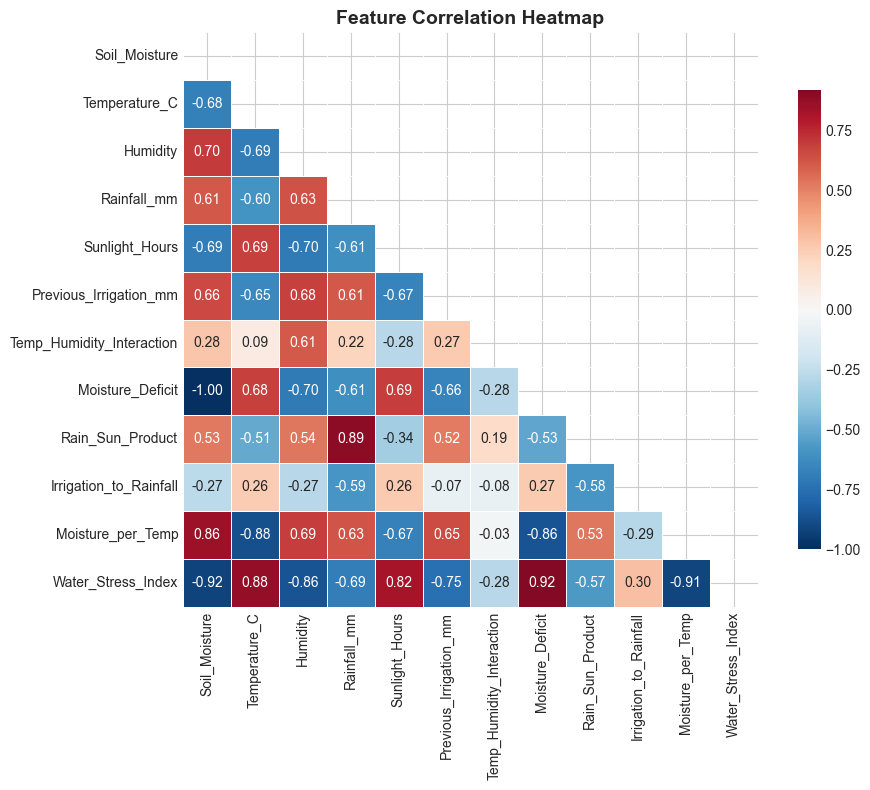

In [7]:
# ============================================================
# STEP 3A — CORRELATION HEATMAP
# ============================================================

print('=== FEATURE CORRELATION ANALYSIS ===')

corr_cols = [c for c in numerical_cols if c != 'Field_Area_hectare']
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, square=True,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [8]:
# ============================================================
# STEP 3B — FEATURE ENGINEERING
# ============================================================
# The new dataset already has all engineered features built in.
# We just confirm they exist and use them directly — no recalculation needed.
# ============================================================

print('=== FEATURE ENGINEERING ===')

df_model = df.copy()

# Features already present in the dataset
new_features = [
    'Temp_Humidity_Interaction',  # Temperature × Humidity
    'Moisture_Deficit',           # 100 - Soil_Moisture (how dry)
    'Rain_Sun_Product',           # Rainfall × Sunlight_Hours
    'Irrigation_to_Rainfall',     # Previous_Irrigation / (Rainfall + 1)
    'Moisture_per_Temp',          # Soil_Moisture / Temperature_C
    'Water_Stress_Index',         # Composite drought signal
]

print('✅ Using pre-engineered features from dataset:')
for f in new_features:
    print(f"   • {f}: min={df_model[f].min():.2f}, max={df_model[f].max():.2f}, mean={df_model[f].mean():.2f}")

# Also capture the 3 categorical bins already in the dataset
cat_bin_features = ['Temp_Category', 'Soil_Moisture_Category', 'Rainfall_Category']
print(f'\n✅ Categorical bin features: {cat_bin_features}')
for f in cat_bin_features:
    print(f"   • {f}: {sorted(df_model[f].unique())}")


=== FEATURE ENGINEERING ===
✅ Using pre-engineered features from dataset:
   • Temp_Humidity_Interaction: min=263.12, max=2668.15, mean=1471.61
   • Moisture_Deficit: min=0.00, max=95.00, mean=49.03
   • Rain_Sun_Product: min=0.00, max=440.60, mean=134.85
   • Irrigation_to_Rainfall: min=0.00, max=4.41, mean=1.59
   • Moisture_per_Temp: min=0.10, max=6.29, mean=2.34
   • Water_Stress_Index: min=0.16, max=0.99, mean=0.51

✅ Categorical bin features: ['Temp_Category', 'Soil_Moisture_Category', 'Rainfall_Category']
   • Temp_Category: ['Cold', 'Hot', 'Mild', 'Warm']
   • Soil_Moisture_Category: ['Dry', 'Moderate', 'Very Dry', 'Wet']
   • Rainfall_Category: ['Heavy', 'Light', 'Moderate', 'No Rain']


In [9]:
# ============================================================
# STEP 3C — ENCODE CATEGORICAL FEATURES
# ============================================================

print('=== ENCODING CATEGORICAL FEATURES ===')

# All object columns except target
categorical_cols = [
    c for c in df_model.select_dtypes(include='object').columns
    if c not in ['Irrigation_Need']
]

label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df_model[f'{col}_enc'] = le.fit_transform(df_model[col].astype(str))
    label_encoders[col] = le
    print(f'   ✓ {col}: {df_model[col].nunique()} unique values → encoded')

# Use our own clean target mapping
target_mapping     = {'Low': 0, 'Medium': 1, 'High': 2}
target_inv_mapping = {0: 'Low', 1: 'Medium', 2: 'High'}
df_model['target'] = df_model['Irrigation_Need'].map(target_mapping)

print('\n✅ Target encoded:')
for k, v in target_mapping.items():
    print(f'   {k:8s} → {v}')


=== ENCODING CATEGORICAL FEATURES ===
   ✓ Soil_Type: 5 unique values → encoded
   ✓ Crop_Type: 10 unique values → encoded
   ✓ Crop_Growth_Stage: 5 unique values → encoded
   ✓ Season: 4 unique values → encoded
   ✓ Region: 5 unique values → encoded
   ✓ Temp_Category: 4 unique values → encoded
   ✓ Soil_Moisture_Category: 4 unique values → encoded
   ✓ Rainfall_Category: 4 unique values → encoded

✅ Target encoded:
   Low      → 0
   Medium   → 1
   High     → 2


In [10]:
# ============================================================
# STEP 3D — SELECT FEATURES & TRAIN/TEST SPLIT
# ============================================================

print('=== FEATURE SELECTION & TRAIN-TEST SPLIT ===')

EXCLUDE_ALWAYS = [
    'Irrigation_Need', 'Irrigation_Need_Encoded', 'target', 'Field_Area_hectare',
]

RAW_FEATURES = [
    'Soil_Moisture', 'Temperature_C', 'Humidity',
    'Rainfall_mm', 'Sunlight_Hours', 'Previous_Irrigation_mm',
]
ENGINEERED_NUM = [
    'Temp_Humidity_Interaction', 'Moisture_Deficit', 'Rain_Sun_Product',
    'Irrigation_to_Rainfall', 'Moisture_per_Temp', 'Water_Stress_Index',
]
encoded_cats = [f'{c}_enc' for c in label_encoders.keys()]

feature_cols = [
    c for c in RAW_FEATURES + ENGINEERED_NUM + encoded_cats
    if c in df_model.columns and c not in EXCLUDE_ALWAYS
]
seen = set()
feature_cols = [c for c in feature_cols if not (c in seen or seen.add(c))]

X = df_model[feature_cols].copy()
y = df_model['target'].copy()

print(f'\n📊 Feature set ({len(feature_cols)} features):')
for c in feature_cols:
    print(f'   • {c}')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'\n✅ Train-Test Split (80/20, stratified):')
print(f'   Training samples : {X_train.shape[0]:,}')
print(f'   Testing  samples : {X_test.shape[0]:,}')
print(f'   Features         : {X_train.shape[1]}')

num_scale_cols = [c for c in RAW_FEATURES + ENGINEERED_NUM if c in X_train.columns]
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()
X_train_scaled[num_scale_cols] = scaler.fit_transform(X_train[num_scale_cols])
X_test_scaled[num_scale_cols]  = scaler.transform(X_test[num_scale_cols])
print(f'\n📏 StandardScaler applied to {len(num_scale_cols)} numerical features')


=== FEATURE SELECTION & TRAIN-TEST SPLIT ===

📊 Feature set (20 features):
   • Soil_Moisture
   • Temperature_C
   • Humidity
   • Rainfall_mm
   • Sunlight_Hours
   • Previous_Irrigation_mm
   • Temp_Humidity_Interaction
   • Moisture_Deficit
   • Rain_Sun_Product
   • Irrigation_to_Rainfall
   • Moisture_per_Temp
   • Water_Stress_Index
   • Soil_Type_enc
   • Crop_Type_enc
   • Crop_Growth_Stage_enc
   • Season_enc
   • Region_enc
   • Temp_Category_enc
   • Soil_Moisture_Category_enc
   • Rainfall_Category_enc

✅ Train-Test Split (80/20, stratified):
   Training samples : 8,800
   Testing  samples : 2,200
   Features         : 20

📏 StandardScaler applied to 12 numerical features


---
## STEP 4 & 5 — Build & Train All Models

In [11]:
# ============================================================
# STEP 4+5 — DEFINE & TRAIN 5 MODELS
# ============================================================
# We train 5 algorithms to find the best performer:
#   1. Logistic Regression         (linear baseline)
#   2. Decision Tree               (interpretable tree)
#   3. K-Nearest Neighbors         (instance-based)
#   4. Random Forest               (ensemble bagging)
#   5. Gradient Boosting           (ensemble boosting)

print('=== TRAINING 5 ML MODELS ===')
print('Using stratified 5-fold cross-validation...\n')

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'Logistic Regression':    LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'Decision Tree':          DecisionTreeClassifier(max_depth=8, class_weight='balanced', random_state=42),
    'K-Nearest Neighbors':    KNeighborsClassifier(n_neighbors=7),
    'Random Forest':          RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1),
    'Gradient Boosting':      GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=4, random_state=42),
}

results = {}

for name, model in models.items():
    # Use scaled data for LR and KNN; raw for tree-based
    if name in ['Logistic Regression', 'K-Nearest Neighbors']:
        Xtr, Xte = X_train_scaled, X_test_scaled
    else:
        Xtr, Xte = X_train, X_test

    # Cross-validation on training set
    cv_scores = cross_val_score(model, Xtr, y_train, cv=cv, scoring='accuracy', n_jobs=-1)

    # Fit on full training set
    model.fit(Xtr, y_train)

    # Predict on test set
    y_pred = model.predict(Xte)

    test_acc = accuracy_score(y_test, y_pred)
    test_f1  = f1_score(y_test, y_pred, average='weighted')

    results[name] = {
        'model':    model,
        'cv_mean':  cv_scores.mean(),
        'cv_std':   cv_scores.std(),
        'test_acc': test_acc,
        'test_f1':  test_f1,
        'y_pred':   y_pred,
        'X_test':   Xte
    }

    status = '🥇' if test_acc > 0.85 else ('🥈' if test_acc > 0.75 else '🥉')
    print(f'{status} {name}')
    print(f'   CV Accuracy : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
    print(f'   Test Accuracy: {test_acc:.4f}   |   Test F1: {test_f1:.4f}')
    print()

=== TRAINING 5 ML MODELS ===
Using stratified 5-fold cross-validation...

🥇 Logistic Regression
   CV Accuracy : 0.8738 ± 0.0070
   Test Accuracy: 0.8732   |   Test F1: 0.8711

🥇 Decision Tree
   CV Accuracy : 0.8690 ± 0.0064
   Test Accuracy: 0.8668   |   Test F1: 0.8645

🥇 K-Nearest Neighbors
   CV Accuracy : 0.8735 ± 0.0060
   Test Accuracy: 0.8723   |   Test F1: 0.8701

🥇 Random Forest
   CV Accuracy : 0.8783 ± 0.0055
   Test Accuracy: 0.8759   |   Test F1: 0.8736

🥇 Gradient Boosting
   CV Accuracy : 0.8756 ± 0.0061
   Test Accuracy: 0.8745   |   Test F1: 0.8721



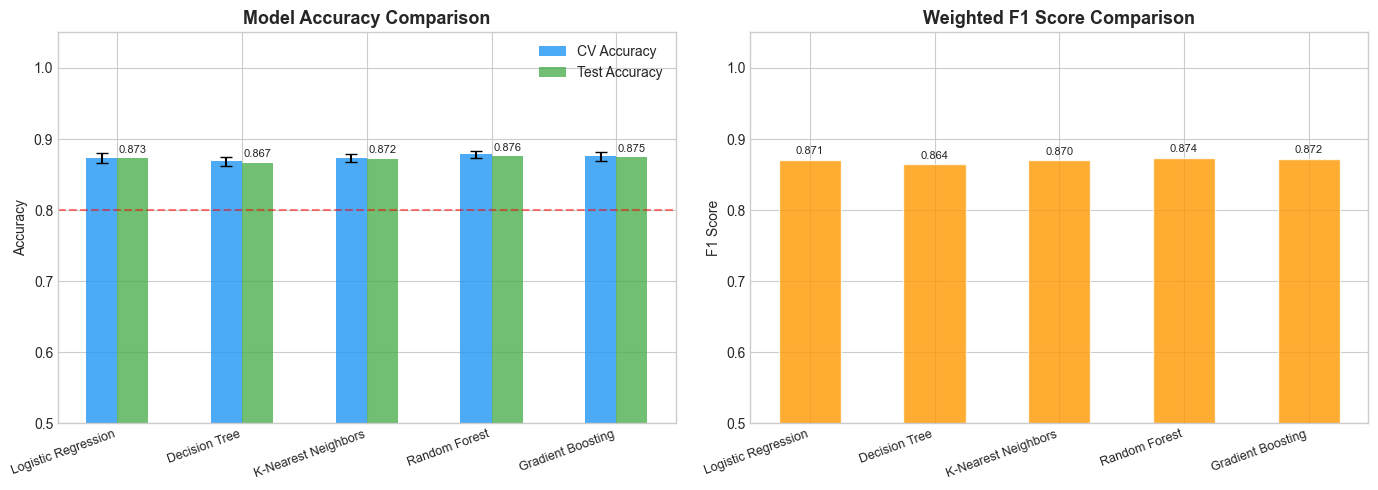


=== MODEL LEADERBOARD ===
  Rank | Model                      | CV Acc     | Test Acc | F1 Score
  ─────┼────────────────────────────┼────────────┼──────────┼─────────
  🥇  1 | Random Forest              | 0.8783±0.005 | 0.8759   | 0.8736
  🥈  2 | Gradient Boosting          | 0.8756±0.006 | 0.8745   | 0.8721
  🥉  3 | Logistic Regression        | 0.8738±0.007 | 0.8732   | 0.8711
  4️⃣   4 | K-Nearest Neighbors        | 0.8735±0.006 | 0.8723   | 0.8701
  5️⃣   5 | Decision Tree              | 0.8690±0.006 | 0.8668   | 0.8645


In [12]:
# ============================================================
# MODEL COMPARISON CHART
# ============================================================

names      = list(results.keys())
cv_means   = [results[n]['cv_mean'] for n in names]
cv_stds    = [results[n]['cv_std']  for n in names]
test_accs  = [results[n]['test_acc'] for n in names]
test_f1s   = [results[n]['test_f1']  for n in names]

x = np.arange(len(names))
width = 0.25

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy comparison
bars1 = axes[0].bar(x - width/2, cv_means,  width, label='CV Accuracy', color='#2196F3', alpha=0.8)
bars2 = axes[0].bar(x + width/2, test_accs, width, label='Test Accuracy', color='#4CAF50', alpha=0.8)
axes[0].errorbar(x - width/2, cv_means, yerr=cv_stds, fmt='none', color='black', capsize=4)
axes[0].set_xticks(x)
axes[0].set_xticklabels(names, rotation=20, ha='right', fontsize=9)
axes[0].set_ylim(0.5, 1.05)
axes[0].set_title('Model Accuracy Comparison', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].axhline(0.8, color='red', linestyle='--', alpha=0.5, label='0.80 threshold')
for bar in bars2:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

# F1 comparison
bars3 = axes[1].bar(x, test_f1s, width*2, color='#FF9800', alpha=0.8, edgecolor='white')
axes[1].set_xticks(x)
axes[1].set_xticklabels(names, rotation=20, ha='right', fontsize=9)
axes[1].set_ylim(0.5, 1.05)
axes[1].set_title('Weighted F1 Score Comparison', fontsize=13, fontweight='bold')
axes[1].set_ylabel('F1 Score')
for bar in bars3:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

# Print leaderboard
print('\n=== MODEL LEADERBOARD ===')
leaderboard = sorted(results.items(), key=lambda x: x[1]['test_acc'], reverse=True)
print(f'  Rank | {"Model":<26} | CV Acc     | Test Acc | F1 Score')
print('  ─────┼────────────────────────────┼────────────┼──────────┼─────────')
for rank, (name, r) in enumerate(leaderboard, 1):
    medal = ['🥇','🥈','🥉','4️⃣ ','5️⃣ '][rank-1]
    print(f'  {medal}  {rank} | {name:<26} | {r["cv_mean"]:.4f}±{r["cv_std"]:.3f} | {r["test_acc"]:.4f}   | {r["test_f1"]:.4f}')

---
## STEP 6 — Hyperparameter Tuning (Best Model)

In [13]:
# ============================================================
# STEP 6 — HYPERPARAMETER TUNING WITH GRID SEARCH
# ============================================================
# We tune the top-2 models for best performance.

print('=== HYPERPARAMETER TUNING ===')

# ---- TUNE RANDOM FOREST ----
print('\n🔧 Tuning Random Forest...')

rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth':    [None, 10, 20],
    'min_samples_split': [2, 5],
    'max_features': ['sqrt', 'log2'],
}

rf_grid = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
    rf_param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
    verbose=0
)
rf_grid.fit(X_train, y_train)
rf_best = rf_grid.best_estimator_
rf_tuned_acc = accuracy_score(y_test, rf_best.predict(X_test))
rf_tuned_f1  = f1_score(y_test, rf_best.predict(X_test), average='weighted')

print(f'  Best params: {rf_grid.best_params_}')
print(f'  CV best score : {rf_grid.best_score_:.4f}')
print(f'  Test Accuracy : {rf_tuned_acc:.4f}')
print(f'  Test F1 Score : {rf_tuned_f1:.4f}')

# ---- TUNE GRADIENT BOOSTING ----
print('\n🔧 Tuning Gradient Boosting...')

gb_param_grid = {
    'n_estimators':  [100, 200],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth':     [3, 4, 6],
    'subsample':     [0.8, 1.0],
}

gb_grid = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    gb_param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
    verbose=0
)
gb_grid.fit(X_train, y_train)
gb_best = gb_grid.best_estimator_
gb_tuned_acc = accuracy_score(y_test, gb_best.predict(X_test))
gb_tuned_f1  = f1_score(y_test, gb_best.predict(X_test), average='weighted')

print(f'  Best params: {gb_grid.best_params_}')
print(f'  CV best score : {gb_grid.best_score_:.4f}')
print(f'  Test Accuracy : {gb_tuned_acc:.4f}')
print(f'  Test F1 Score : {gb_tuned_f1:.4f}')

# Choose best tuned model
if rf_tuned_acc >= gb_tuned_acc:
    best_model      = rf_best
    best_model_name = 'Random Forest (Tuned)'
    best_acc        = rf_tuned_acc
else:
    best_model      = gb_best
    best_model_name = 'Gradient Boosting (Tuned)'
    best_acc        = gb_tuned_acc

print(f'\n🏆 Best tuned model: {best_model_name} (Test Accuracy: {best_acc:.4f})')

=== HYPERPARAMETER TUNING ===

🔧 Tuning Random Forest...
  Best params: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 100}
  CV best score : 0.8794
  Test Accuracy : 0.8782
  Test F1 Score : 0.8758

🔧 Tuning Gradient Boosting...
  Best params: {'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 100, 'subsample': 0.8}
  CV best score : 0.8781
  Test Accuracy : 0.8750
  Test F1 Score : 0.8727

🏆 Best tuned model: Random Forest (Tuned) (Test Accuracy: 0.8782)


---
## STEP 7 — Full Evaluation of Best Model

In [14]:
# ============================================================
# STEP 7A — CLASSIFICATION REPORT
# ============================================================

y_pred_best = best_model.predict(X_test)
class_names = ['Low', 'Medium', 'High']

print(f'=== FULL EVALUATION — {best_model_name} ===')
print('\n📊 Classification Report:')
print(classification_report(y_test, y_pred_best, target_names=class_names, digits=4))

# Summary metrics
print('📈 Summary Metrics:')
print(f'   Accuracy  : {accuracy_score(y_test, y_pred_best):.4f}')
print(f'   F1 (macro): {f1_score(y_test, y_pred_best, average="macro"):.4f}')
print(f'   F1 (wt)   : {f1_score(y_test, y_pred_best, average="weighted"):.4f}')
print(f'   Precision : {precision_score(y_test, y_pred_best, average="weighted"):.4f}')
print(f'   Recall    : {recall_score(y_test, y_pred_best, average="weighted"):.4f}')

=== FULL EVALUATION — Random Forest (Tuned) ===

📊 Classification Report:
              precision    recall  f1-score   support

         Low     0.8798    0.9620    0.9191      1080
      Medium     0.8735    0.7623    0.8141       770
        High     0.8818    0.8743    0.8780       350

    accuracy                         0.8782      2200
   macro avg     0.8784    0.8662    0.8704      2200
weighted avg     0.8779    0.8782    0.8758      2200

📈 Summary Metrics:
   Accuracy  : 0.8782
   F1 (macro): 0.8704
   F1 (wt)   : 0.8758
   Precision : 0.8779
   Recall    : 0.8782


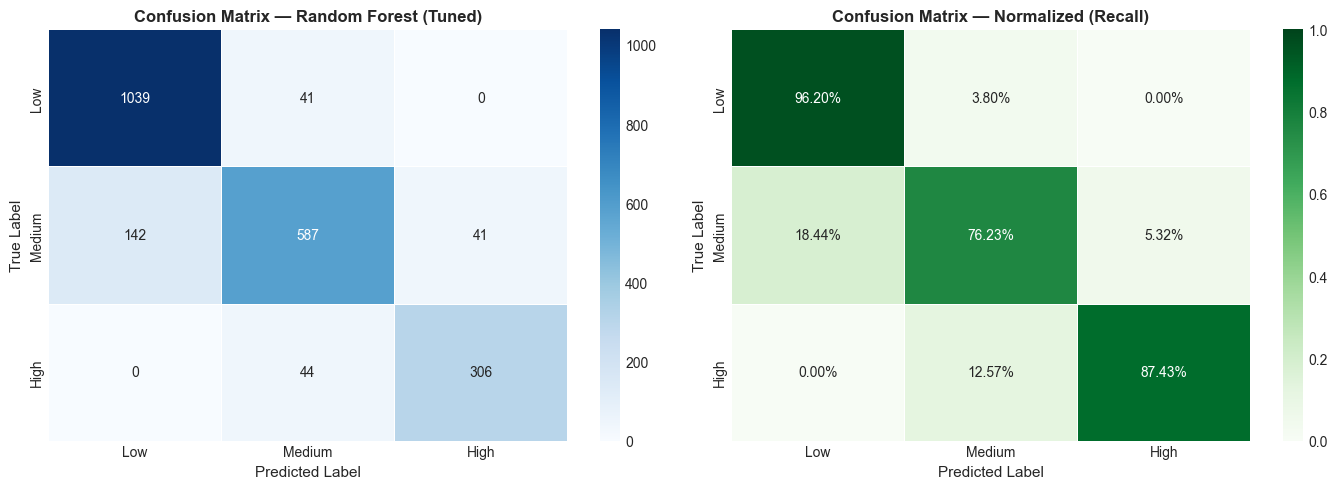

In [15]:
# ============================================================
# STEP 7B — CONFUSION MATRIX
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw counts
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            ax=axes[0], linewidths=0.5)
axes[0].set_title(f'Confusion Matrix — {best_model_name}', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted Label', fontsize=11)
axes[0].set_ylabel('True Label', fontsize=11)

# Normalized (recall per class)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names,
            ax=axes[1], linewidths=0.5, vmin=0, vmax=1)
axes[1].set_title('Confusion Matrix — Normalized (Recall)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Predicted Label', fontsize=11)
axes[1].set_ylabel('True Label', fontsize=11)

plt.tight_layout()
plt.show()

=== TOP FEATURE IMPORTANCES ===
  Water_Stress_Index            : 0.2434  ████████████████████████
  Moisture_per_Temp             : 0.1294  ████████████
  Soil_Moisture_Category_enc    : 0.1094  ██████████
  Rainfall_mm                   : 0.0890  ████████
  Previous_Irrigation_mm        : 0.0794  ███████
  Rainfall_Category_enc         : 0.0649  ██████
  Humidity                      : 0.0562  █████
  Sunlight_Hours                : 0.0437  ████
  Moisture_Deficit              : 0.0426  ████
  Soil_Moisture                 : 0.0331  ███


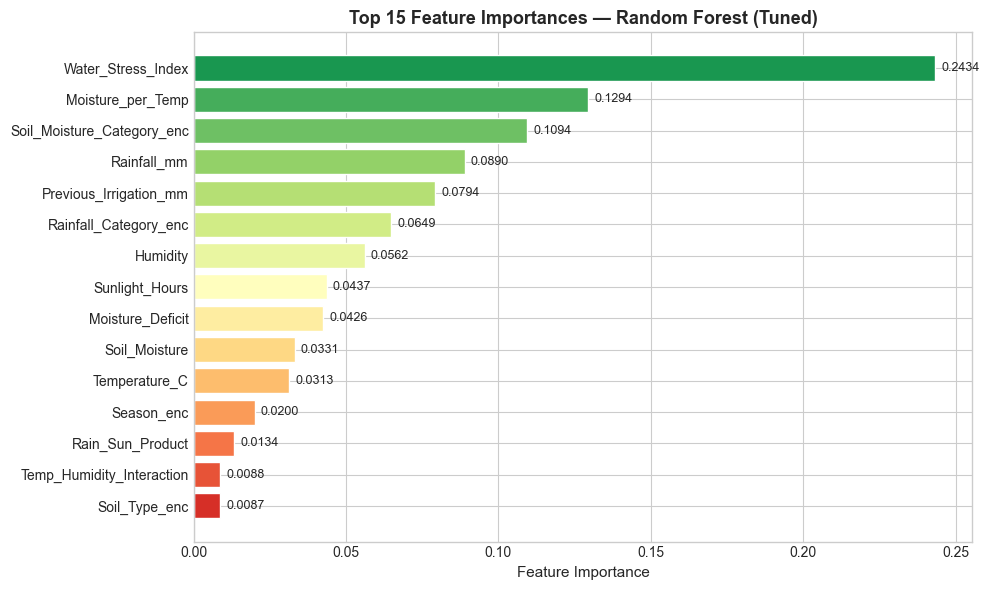

In [16]:
# ============================================================
# STEP 7C — FEATURE IMPORTANCE
# ============================================================

if hasattr(best_model, 'feature_importances_'):
    importances = pd.Series(best_model.feature_importances_, index=feature_cols)
    importances = importances.sort_values(ascending=False)

    print('=== TOP FEATURE IMPORTANCES ===')
    for feat, imp in importances.head(10).items():
        bar = '█' * int(imp * 100)
        print(f'  {feat:<30s}: {imp:.4f}  {bar}')

    plt.figure(figsize=(10, 6))
    top_n = min(15, len(importances))
    top_imp = importances.head(top_n)
    colors_imp = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, top_n))
    bars = plt.barh(range(top_n), top_imp.values[::-1],
                    color=colors_imp[::-1], edgecolor='white')
    plt.yticks(range(top_n), top_imp.index[::-1])
    plt.xlabel('Feature Importance', fontsize=11)
    plt.title(f'Top {top_n} Feature Importances — {best_model_name}', fontsize=13, fontweight='bold')
    for i, bar in enumerate(bars):
        plt.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
                 f'{bar.get_width():.4f}', va='center', fontsize=9)
    plt.tight_layout()
    plt.show()

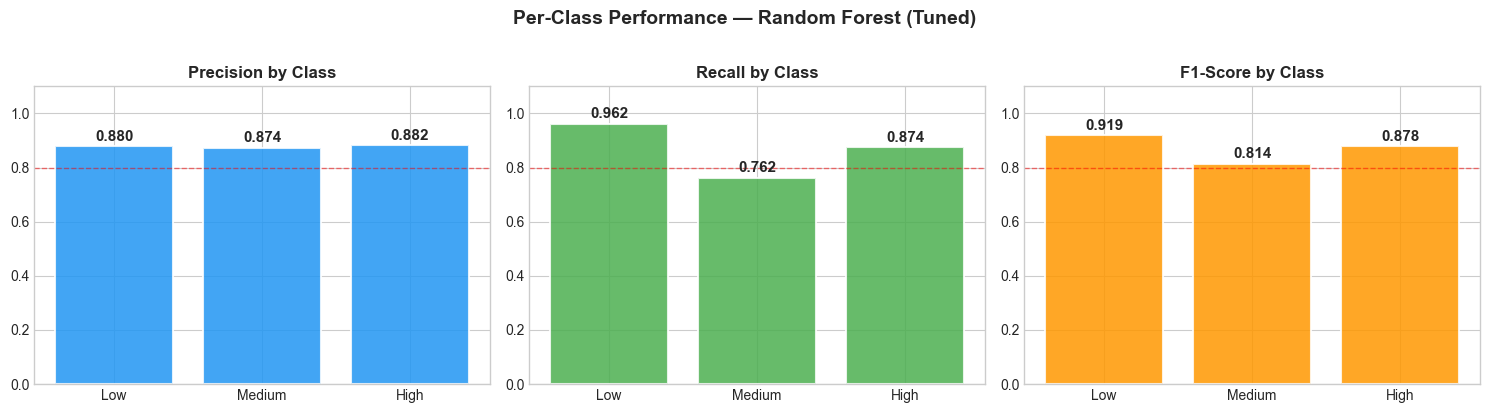

In [17]:
# ============================================================
# STEP 7D — PER-CLASS PERFORMANCE BREAKDOWN
# ============================================================

from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, support = precision_recall_fscore_support(y_test, y_pred_best)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
metrics = [('Precision', precision), ('Recall', recall), ('F1-Score', f1)]
colors_m = ['#2196F3', '#4CAF50', '#FF9800']

for ax, (metric_name, values), color in zip(axes, metrics, colors_m):
    bars = ax.bar(class_names, values, color=color, alpha=0.85, edgecolor='white', linewidth=1.5)
    ax.set_title(f'{metric_name} by Class', fontsize=12, fontweight='bold')
    ax.set_ylim(0, 1.1)
    ax.axhline(0.8, color='red', linestyle='--', alpha=0.5, linewidth=1)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{bar.get_height():.3f}', ha='center', fontsize=11, fontweight='bold')

plt.suptitle(f'Per-Class Performance — {best_model_name}', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## STEP 8 — Save Model & Artifacts

In [18]:
# ============================================================
# STEP 8 — SAVE MODEL & ALL ARTIFACTS
# ============================================================

import os, joblib

output_dir = 'model_artifacts'
os.makedirs(output_dir, exist_ok=True)

# Save model
model_path = os.path.join(output_dir, 'best_irrigation_model.pkl')
joblib.dump(best_model, model_path)

# Save scaler
scaler_path = os.path.join(output_dir, 'scaler.pkl')
joblib.dump(scaler, scaler_path)

# Save label encoders
le_path = os.path.join(output_dir, 'label_encoders.pkl')
joblib.dump(label_encoders, le_path)

# Save feature list
feat_path = os.path.join(output_dir, 'feature_cols.pkl')
joblib.dump(feature_cols, feat_path)

# Save target mapping
map_path = os.path.join(output_dir, 'target_mapping.pkl')
joblib.dump({'mapping': target_mapping, 'inverse': target_inv_mapping}, map_path)

print('✅ All artifacts saved:')
for f in os.listdir(output_dir):
    size = os.path.getsize(os.path.join(output_dir, f))
    print(f'   📦 {f} ({size/1024:.1f} KB)')

✅ All artifacts saved:
   📦 best_irrigation_model.pkl (3184.6 KB)
   📦 feature_cols.pkl (0.4 KB)
   📦 label_encoders.pkl (2.4 KB)
   📦 scaler.pkl (1.3 KB)
   📦 target_mapping.pkl (0.1 KB)


In [19]:
# ============================================================
# LIVE PREDICTION FUNCTION
# ============================================================

def predict_irrigation(input_data: dict) -> dict:
    row = pd.DataFrame([input_data])

    # ── 6 engineered features ────────────────────────────────
    row['Temp_Humidity_Interaction'] = row['Temperature_C'] * row['Humidity']
    row['Moisture_Deficit']          = 100 - row['Soil_Moisture']
    row['Rain_Sun_Product']          = row['Rainfall_mm'] * row['Sunlight_Hours']
    row['Irrigation_to_Rainfall']    = row['Previous_Irrigation_mm'] / (row['Rainfall_mm'] + 1)
    row['Moisture_per_Temp']         = row['Soil_Moisture'] / row['Temperature_C']
    row['Water_Stress_Index']        = (
        (100 - row['Soil_Moisture']) / 100 * 0.4 +
        (row['Temperature_C'] / 42) * 0.3 +
        (1 - row['Humidity'] / 100) * 0.2 +
        (row['Sunlight_Hours'] / 12) * 0.1
    )

    # ── 3 categorical bin columns ─────────────────────────────
    row['Temp_Category'] = pd.cut(
        row['Temperature_C'],
        bins=[0, 20, 25, 30, 100],
        labels=['Cold', 'Mild', 'Warm', 'Hot']
    ).astype(str)

    row['Soil_Moisture_Category'] = pd.cut(
        row['Soil_Moisture'],
        bins=[0, 30, 50, 70, 100],
        labels=['Very Dry', 'Dry', 'Moderate', 'Wet']
    ).astype(str)

    row['Rainfall_Category'] = pd.cut(
        row['Rainfall_mm'],
        bins=[-1, 10, 30, 50, 1000],
        labels=['No Rain', 'Light', 'Moderate', 'Heavy']
    ).astype(str)

    # ── Encode categoricals ───────────────────────────────────
    for col, le in label_encoders.items():
        if col in row.columns:
            try:
                row[f'{col}_enc'] = le.transform(row[col].astype(str))
            except ValueError:
                row[f'{col}_enc'] = 0  # unseen label fallback

    # ── Align & predict ───────────────────────────────────────
    X_input    = row[feature_cols]
    pred_class = best_model.predict(X_input)[0]
    proba      = best_model.predict_proba(X_input)[0]

    label       = target_inv_mapping[pred_class]
    class_probs = {target_inv_mapping[i]: round(float(p), 4) for i, p in enumerate(proba)}

    return {
        'prediction':    label,
        'confidence':    round(float(max(proba)), 4),
        'probabilities': class_probs
    }


# ── DEMO PREDICTION ──────────────────────────────────────────
demo_farm = {
    'Soil_Moisture':          25.0,
    'Temperature_C':          35.0,
    'Humidity':               40.0,
    'Rainfall_mm':             2.0,
    'Sunlight_Hours':          9.0,
    'Previous_Irrigation_mm': 10.0,
    'Soil_Type':            'Sandy',
    'Crop_Type':            'Maize',
    'Crop_Growth_Stage':    'Flowering',
    'Season':               'Summer',
    'Region':               'North',
}

result = predict_irrigation(demo_farm)
print('=== DEMO PREDICTION ===')
print(f"  Farm Conditions : Dry soil (25%), Hot temp (35°C), Low rain (2mm)")
print(f"  Prediction      : {result['prediction']} irrigation need")
print(f"  Confidence      : {result['confidence']*100:.1f}%")
print(f"  Probabilities   : Low={result['probabilities']['Low']:.2%}  "
      f"Medium={result['probabilities']['Medium']:.2%}  "
      f"High={result['probabilities']['High']:.2%}")


=== DEMO PREDICTION ===
  Farm Conditions : Dry soil (25%), Hot temp (35°C), Low rain (2mm)
  Prediction      : High irrigation need
  Confidence      : 94.8%
  Probabilities   : Low=0.01%  Medium=5.18%  High=94.82%


In [20]:
# ============================================================
# FINAL SUMMARY
# ============================================================

print('=' * 60)
print('  🏆  ML PIPELINE COMPLETE — FINAL SUMMARY')
print('=' * 60)
print(f'''
  Project : Smart Irrigation Decision Support System
  Developer: IMANI NZEYIMANA David

  Dataset  : {df.shape[0]} samples | {len(feature_cols)} features
  Target   : Irrigation_Need (Low / Medium / High)

  Models Trained    : 5 algorithms compared
  Best Model        : {best_model_name}
  Test Accuracy     : {best_acc:.4f} ({best_acc*100:.2f}%)

  Artifacts Saved:
    • best_irrigation_model.pkl
    • scaler.pkl
    • label_encoders.pkl
    • feature_cols.pkl
    • target_mapping.pkl

  
''')
print('=' * 60)

  🏆  ML PIPELINE COMPLETE — FINAL SUMMARY

  Project : Smart Irrigation Decision Support System
  Developer: IMANI NZEYIMANA David

  Dataset  : 11000 samples | 20 features
  Target   : Irrigation_Need (Low / Medium / High)

  Models Trained    : 5 algorithms compared
  Best Model        : Random Forest (Tuned)
  Test Accuracy     : 0.8782 (87.82%)

  Artifacts Saved:
    • best_irrigation_model.pkl
    • scaler.pkl
    • label_encoders.pkl
    • feature_cols.pkl
    • target_mapping.pkl



